In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV

In [130]:
df = pd.read_csv("fetal_health.csv")

df.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


# Exploratory Data Analsys

In [161]:
df["fetal_health"].value_counts()

fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

<Axes: xlabel='fetal_health'>

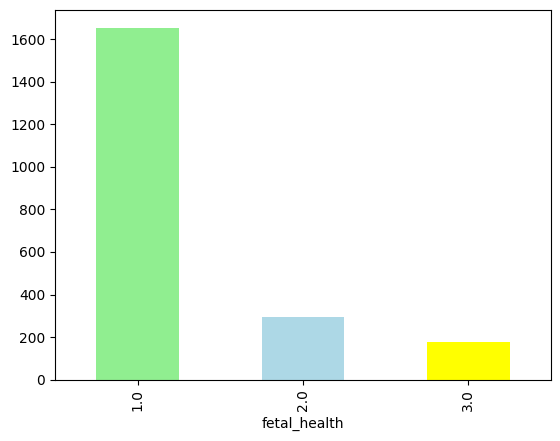

In [131]:
df["fetal_health"].value_counts().plot(kind="bar", color=["lightgreen", "lightblue", "yellow"])

In [132]:
df.info() #para verificar se há dados ausentes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

<Axes: >

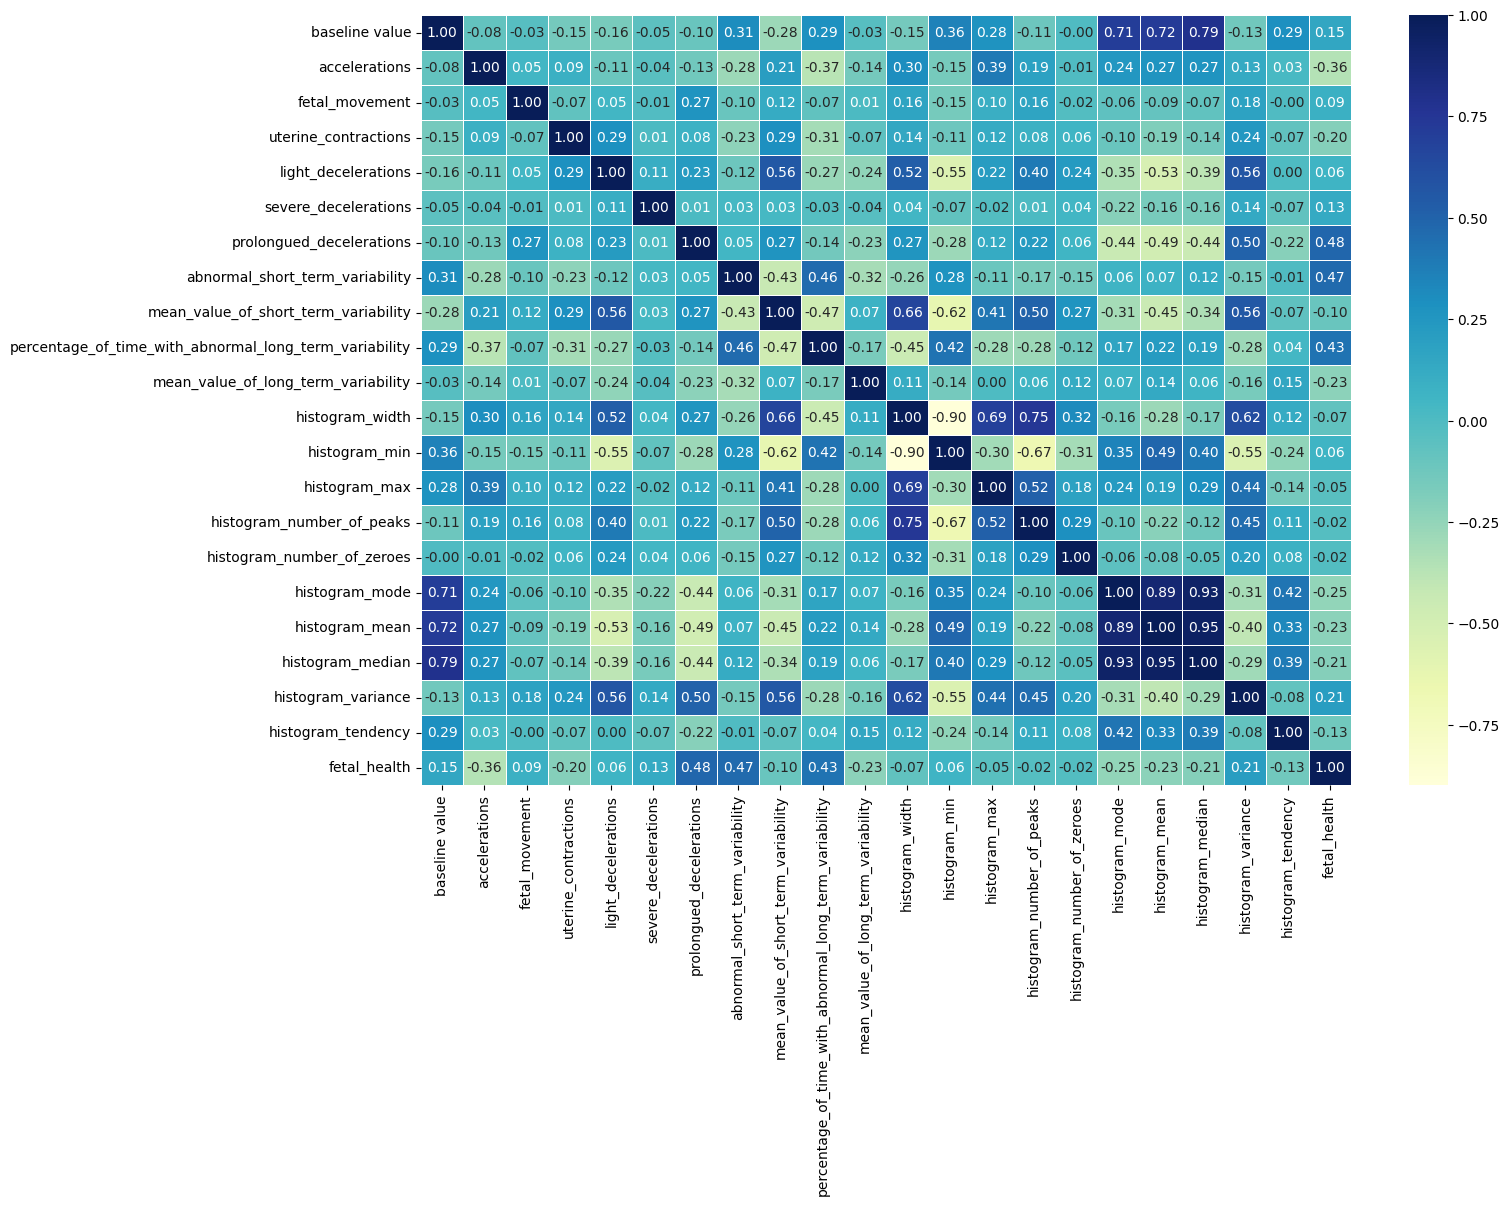

In [133]:
# comparar as variaveis para encontrar variaveis importantes
# Ele mostra a relação entre as variáveis do dataset real, e não do dataset alterado pelo balanceamento.
# Balanceamento muda apenas a quantidade de linhas, não muda as colunas nem seus valores, então a correlação continua sendo representativa.
corr_matrix = df.corr()
plt.figure(figsize=(15,10))

sns.heatmap(corr_matrix, annot=True, linewidths=0.5, fmt=".2f", cmap="YlGnBu")

# Data Preprocessing

In [134]:
X = df.drop(columns="fetal_health")
y = df["fetal_health"]

In [135]:
X.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0


In [136]:
y.head()

0    2.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: fetal_health, dtype: float64

# Train and Test

## Split data

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
        X, 
        y, 
        test_size = 0.3, 
        random_state = 3, 
        stratify = y
    )

## K-Neighbors Classifier

In [138]:
from  sklearn.neighbors import KNeighborsClassifier

In [139]:
KNfetal_ai = KNeighborsClassifier()

KNfetal_ai.fit(X_train, y_train)

KNfetal_ai.score(X_test,y_test)

0.8714733542319749

### Confusion Matrix

In [140]:
y_preds = KNfetal_ai.predict(X_test)
confusion_mx = confusion_matrix(y_test, y_preds)
print(confusion_mx)

[[475  19   3]
 [ 42  43   3]
 [  9   6  38]]


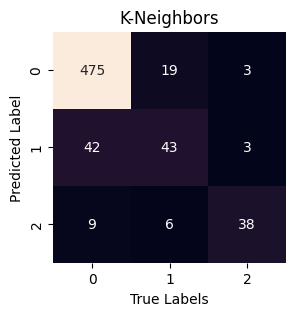

In [141]:
fig, ax = plt.subplots(figsize= (3,3))
ax = sns.heatmap(confusion_mx, annot=True, cbar =False, fmt='d')
plt.title("K-Neighbors")
plt.xlabel("True Labels")
plt.ylabel("Predicted Label");

### Classification Report

In [142]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

         1.0       0.90      0.96      0.93       497
         2.0       0.63      0.49      0.55        88
         3.0       0.86      0.72      0.78        53

    accuracy                           0.87       638
   macro avg       0.80      0.72      0.75       638
weighted avg       0.86      0.87      0.86       638



## Logistic Regression Classifier

In [143]:
from sklearn.linear_model import LogisticRegression

In [144]:
LRfetal_ai = LogisticRegression()

LRfetal_ai.fit(X_train, y_train)

LRfetal_ai.score(X_test,y_test)


/home/moises/Projects/VsCode/IAParaSaude/trabalho_final/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8573667711598746

### Confusion Matrix

In [145]:
y_preds = LRfetal_ai.predict(X_test)
confusion_mx = confusion_matrix(y_test, y_preds)
print(confusion_mx)

[[478  12   7]
 [ 53  32   3]
 [  8   8  37]]


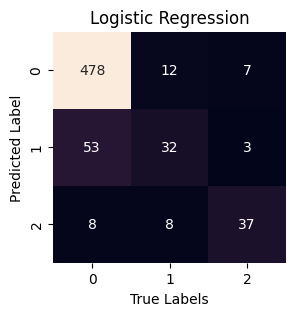

In [146]:
fig, ax = plt.subplots(figsize= (3,3))
ax = sns.heatmap(confusion_mx, annot=True, cbar =False, fmt='d')
plt.title("Logistic Regression")
plt.xlabel("True Labels")
plt.ylabel("Predicted Label");

### Classification Report

In [147]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

         1.0       0.89      0.96      0.92       497
         2.0       0.62      0.36      0.46        88
         3.0       0.79      0.70      0.74        53

    accuracy                           0.86       638
   macro avg       0.76      0.67      0.71       638
weighted avg       0.84      0.86      0.84       638



# Random Forest

In [148]:
from sklearn.ensemble import RandomForestClassifier

In [149]:
RFfetal_ai = RandomForestClassifier()

RFfetal_ai.fit(X_train, y_train)

RFfetal_ai.score(X_test,y_test)

0.9216300940438872

### Confusion Matrix

In [150]:
y_preds = RFfetal_ai.predict(X_test)
confusion_mx = confusion_matrix(y_test, y_preds)
print(confusion_mx)

[[483  13   1]
 [ 23  62   3]
 [  8   2  43]]


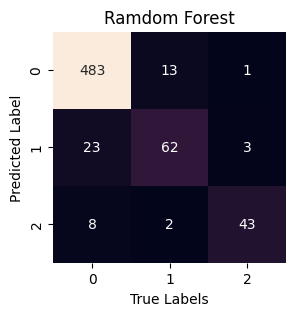

In [151]:
fig, ax = plt.subplots(figsize= (3,3))
ax = sns.heatmap(confusion_mx, annot=True, cbar =False, fmt='d')
plt.title("Ramdom Forest")
plt.xlabel("True Labels")
plt.ylabel("Predicted Label");

### Classification Report

In [152]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

         1.0       0.94      0.97      0.96       497
         2.0       0.81      0.70      0.75        88
         3.0       0.91      0.81      0.86        53

    accuracy                           0.92       638
   macro avg       0.89      0.83      0.86       638
weighted avg       0.92      0.92      0.92       638



# Cross Validation to Ramdom Forest

In [153]:
rf_grid = {
    "n_estimators": np.arange(10,1000, 50), #começa em 10, vai ate 1000 e com passos de 50 em 50, numero de arvores
    "max_depth": [None,3, 5, 10], # ṕrofundiade
    "min_samples_split": np.arange(2,20,2), #representa o numero minimo de amosta pra dividir um nó
    "min_samples_leaf": np.arange(1,20,2)
}

In [ ]:
cv_RFfetal_ai = RandomizedSearchCV(RandomForestClassifier(),param_distributions= rf_grid, cv = 5, n_iter=20,verbose=True)

cv_RFfetal_ai.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [158]:
cv_RFfetal_ai.best_params_

{'n_estimators': np.int64(560),
 'min_samples_split': np.int64(2),
 'min_samples_leaf': np.int64(3),
 'max_depth': None}

In [157]:
cv_RFfetal_ai.score(X_test,y_test)


0.9106583072100314

In [159]:
y_preds = cv_RFfetal_ai.predict(X_test)
confusion_mx = confusion_matrix(y_test, y_preds)
print(confusion_mx)

[[479  15   3]
 [ 27  60   1]
 [  9   2  42]]


In [160]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

         1.0       0.93      0.96      0.95       497
         2.0       0.78      0.68      0.73        88
         3.0       0.91      0.79      0.85        53

    accuracy                           0.91       638
   macro avg       0.87      0.81      0.84       638
weighted avg       0.91      0.91      0.91       638



# Leitura dos dados + preparação

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from imblearn.under_sampling import RandomUnderSampler

# ===========================
# LEITURA DO DATASET
# ===========================
df = pd.read_csv("fetal_health.csv")
df = df.apply(pd.to_numeric, errors="coerce")
df = df.fillna(df.mean())

df.head()


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


# Gráfico de distribuição ANTES do balanceamento

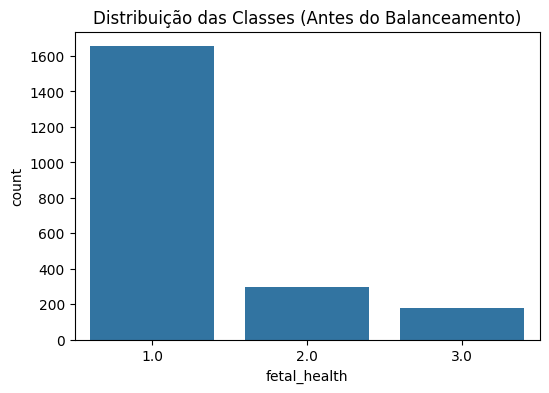

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="fetal_health")
plt.title("Distribuição das Classes (Antes do Balanceamento)")
plt.show()

In [34]:
#Separar X e y
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"].astype(int)

In [35]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Treino ANTES do balanceamento + matriz de confusão

<Figure size 600x600 with 0 Axes>

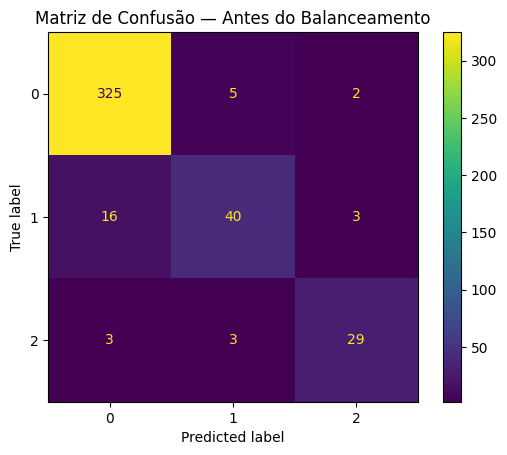


 CLASSIFICATION REPORT (Antes):
              precision    recall  f1-score   support

           1       0.94      0.98      0.96       332
           2       0.83      0.68      0.75        59
           3       0.85      0.83      0.84        35

    accuracy                           0.92       426
   macro avg       0.88      0.83      0.85       426
weighted avg       0.92      0.92      0.92       426



In [36]:
model_before = RandomForestClassifier(random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

cm_before = confusion_matrix(y_test, y_pred_before)
disp_before = ConfusionMatrixDisplay(cm_before)

plt.figure(figsize=(6,6))
disp_before.plot(cmap="viridis")
plt.title("Matriz de Confusão — Antes do Balanceamento")
plt.show()

print("\n CLASSIFICATION REPORT (Antes):")
print(classification_report(y_test, y_pred_before))

In [37]:
#Balanceamento dos dados (RandomUnderSampler)
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

# Gráfico de barras DEPOIS do balanceamento

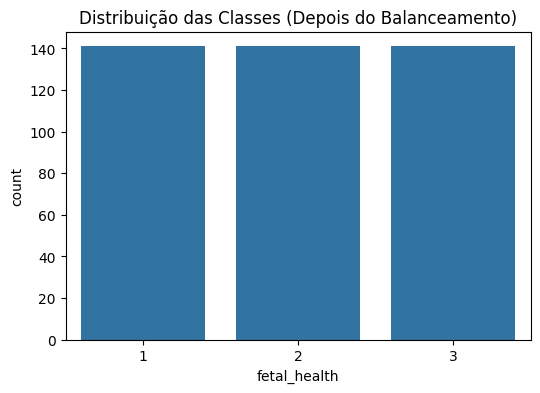

In [38]:
df_bal = pd.DataFrame({"fetal_health": y_train_bal})

plt.figure(figsize=(6,4))
sns.countplot(data=df_bal, x="fetal_health")
plt.title("Distribuição das Classes (Depois do Balanceamento)")
plt.show()

# Treino DEPOIS do balanceamento + matriz de confusão

<Figure size 600x600 with 0 Axes>

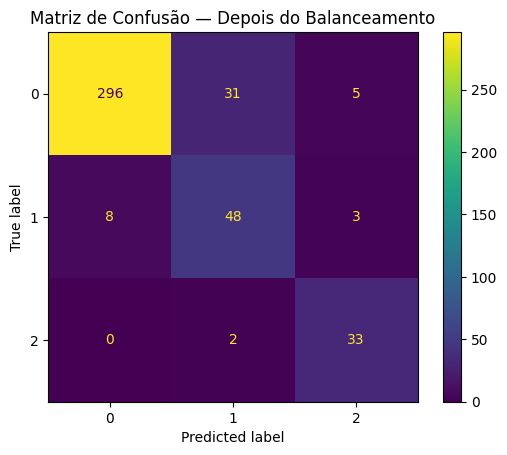


 CLASSIFICATION REPORT (Depois):
              precision    recall  f1-score   support

           1       0.97      0.89      0.93       332
           2       0.59      0.81      0.69        59
           3       0.80      0.94      0.87        35

    accuracy                           0.88       426
   macro avg       0.79      0.88      0.83       426
weighted avg       0.91      0.88      0.89       426



In [39]:
model_after = RandomForestClassifier(random_state=42)
model_after.fit(X_train_bal, y_train_bal)

y_pred_after = model_after.predict(X_test)

cm_after = confusion_matrix(y_test, y_pred_after)
disp_after = ConfusionMatrixDisplay(cm_after)

plt.figure(figsize=(6,6))
disp_after.plot(cmap="viridis")
plt.title("Matriz de Confusão — Depois do Balanceamento")
plt.show()

print("\n CLASSIFICATION REPORT (Depois):")
print(classification_report(y_test, y_pred_after))

In [40]:
df = pd.read_csv("fetal_health.csv")#para verificar se há dados ausentes

df.info()       # ✔ Verifica dados ausentes
df.describe()   # ✔ Estatísticas gerais

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,0.003178,0.009481,0.004366,0.001889,0.000003,0.000159,46.990122,1.332785,9.84666,...,93.579492,164.025400,4.068203,0.323612,137.452023,134.610536,138.090310,18.808090,0.320320,1.304327
std,9.840844,0.003866,0.046666,0.002946,0.002960,0.000057,0.000590,17.192814,0.883241,18.39688,...,29.560212,17.944183,2.949386,0.706059,16.381289,15.593596,14.466589,28.977636,0.610829,0.614377
min,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.00000,...,50.000000,122.000000,0.000000,0.000000,60.000000,73.000000,77.000000,0.000000,-1.000000,1.000000
25%,126.000000,0.000000,0.000000,0.002000,0.000000,0.000000,0.000000,32.000000,0.700000,0.00000,...,67.000000,152.000000,2.000000,0.000000,129.000000,125.000000,129.000000,2.000000,0.000000,1.000000
50%,133.000000,0.002000,0.000000,0.004000,0.000000,0.000000,0.000000,49.000000,1.200000,0.00000,...,93.000000,162.000000,3.000000,0.000000,139.000000,136.000000,139.000000,7.000000,0.000000,1.000000
75%,140.000000,0.006000,0.003000,0.007000,0.003000,0.000000,0.000000,61.000000,1.700000,11.00000,...,120.000000,174.000000,6.000000,0.000000,148.000000,145.000000,148.000000,24.000000,1.000000,1.000000
max,160.000000,0.019000,0.481000,0.015000,0.015000,0.001000,0.005000,87.000000,7.000000,91.00000,...,159.000000,238.000000,18.000000,10.000000,187.000000,182.000000,186.000000,269.000000,1.000000,3.000000
